In [7]:
query = "Artificial Intelligence in medicine"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)

for sentence, score in zip(sentences, scores[0]):
    print(f"{score:.3f} - {sentence}")

0.676 - Artificial Intelligence is transforming healthcare.
0.653 - AI is changing the medical industry.
0.001 - I enjoy playing football.
0.233 - Machine Learning improves search engines.


In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "Artificial Intelligence improves healthcare.",
    "Machine Learning powers recommendation systems.",
    "Football is a popular sport.",
    "Python is widely used for data science.",
    "Doctors use AI to detect diseases."
]

doc_embeddings = model.encode(documents)

query = "AI in medicine"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, doc_embeddings)[0]

ranked = np.argsort(scores)[::-1]

print("Semantic Search Results\n")

for idx in ranked:
    print(f"Score: {scores[idx]:.3f}")
    print(documents[idx])
    print("-"*50)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semantic Search Results

Score: 0.796
Doctors use AI to detect diseases.
--------------------------------------------------
Score: 0.698
Artificial Intelligence improves healthcare.
--------------------------------------------------
Score: 0.202
Python is widely used for data science.
--------------------------------------------------
Score: 0.135
Machine Learning powers recommendation systems.
--------------------------------------------------
Score: 0.067
Football is a popular sport.
--------------------------------------------------


In [9]:
from itertools import combinations

sentences = [
    "AI is transforming healthcare.",
    "Artificial Intelligence is changing medicine.",
    "I enjoy playing cricket.",
    "Hospitals use AI for diagnosis."
]

embeddings = model.encode(sentences)

for i, j in combinations(range(len(sentences)), 2):
    score = cosine_similarity(
        [embeddings[i]],
        [embeddings[j]]
    )[0][0]

    print(f"{sentences[i]}")
    print(f"{sentences[j]}")
    print(f"Similarity: {score:.3f}")
    print("-"*60)

AI is transforming healthcare.
Artificial Intelligence is changing medicine.
Similarity: 0.786
------------------------------------------------------------
AI is transforming healthcare.
I enjoy playing cricket.
Similarity: 0.043
------------------------------------------------------------
AI is transforming healthcare.
Hospitals use AI for diagnosis.
Similarity: 0.724
------------------------------------------------------------
Artificial Intelligence is changing medicine.
I enjoy playing cricket.
Similarity: 0.052
------------------------------------------------------------
Artificial Intelligence is changing medicine.
Hospitals use AI for diagnosis.
Similarity: 0.604
------------------------------------------------------------
I enjoy playing cricket.
Hospitals use AI for diagnosis.
Similarity: -0.071
------------------------------------------------------------


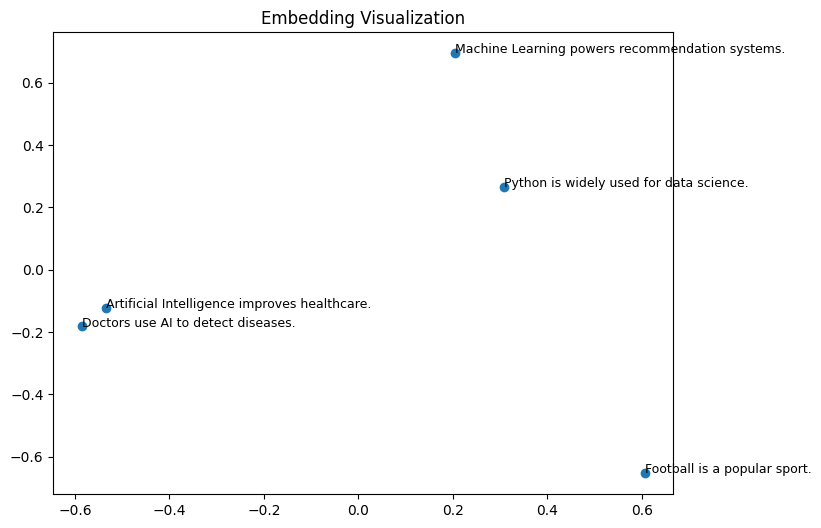

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings = model.encode(documents)

pca = PCA(n_components=2)

points = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(points[:,0], points[:,1])

for i, text in enumerate(documents):
    plt.text(points[i,0], points[i,1], text, fontsize=9)

plt.title("Embedding Visualization")

plt.show()

In [11]:
courses = [
    "Deep Learning",
    "Python Programming",
    "Machine Learning",
    "Web Development",
    "Data Science",
    "Artificial Intelligence"
]

course_embeddings = model.encode(courses)

user_interest = "AI"

interest_embedding = model.encode([user_interest])

scores = cosine_similarity(
    interest_embedding,
    course_embeddings
)[0]

ranking = np.argsort(scores)[::-1]

print("Recommended Courses\n")

for i in ranking:
    print(f"{courses[i]}  ({scores[i]:.3f})")

Recommended Courses

Artificial Intelligence  (0.791)
Machine Learning  (0.546)
Deep Learning  (0.474)
Data Science  (0.409)
Python Programming  (0.320)
Web Development  (0.227)
